## Метод опорных векторов

## SVM

**1.** Сгенерируйте три случайные двумерные выборки для бинарной классификации (хотя бы по 400 точек в каждой):
- с линейно разделимыми классами;
- с хорошо разделимыми классами, но не линейно разделимыми;
- с плохо разделимыми классами.

Визуализируйте полученные выборки на плоскости.

Для генерации случайной выборки можно использовать функции из модуля [sklearn.datasets](http://scikit-learn.org/stable/modules/classes.html#module-sklearn.datasets).

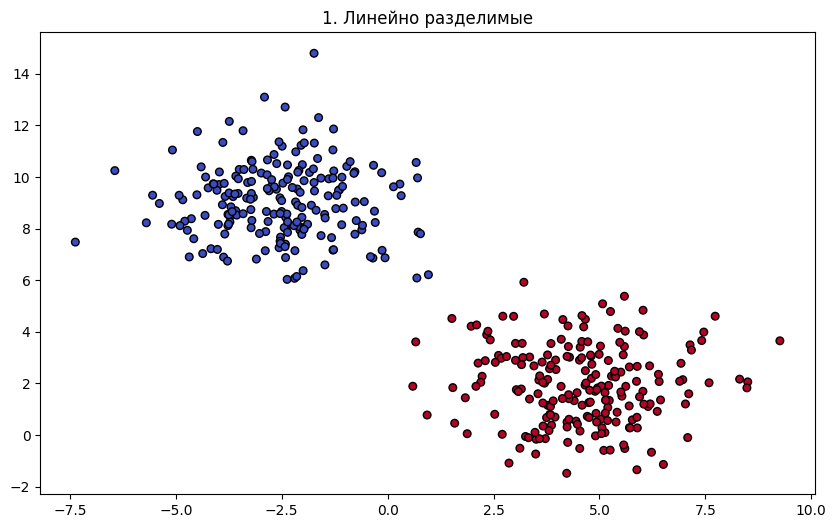

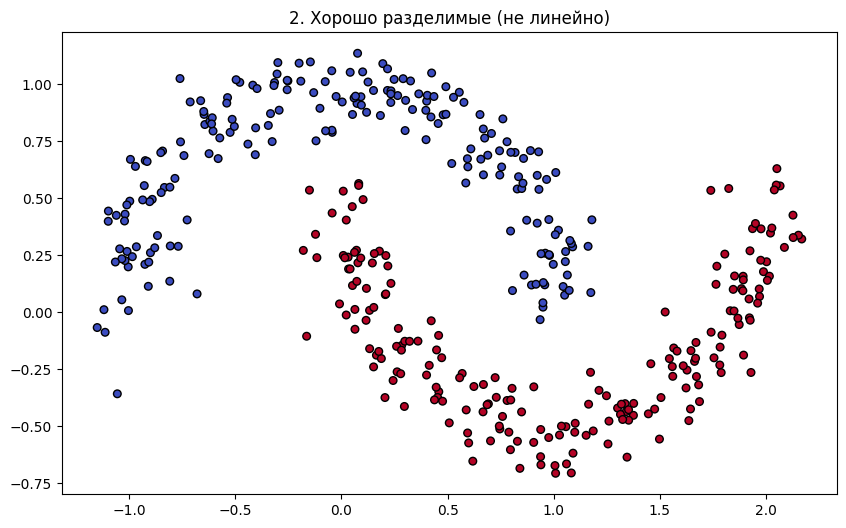

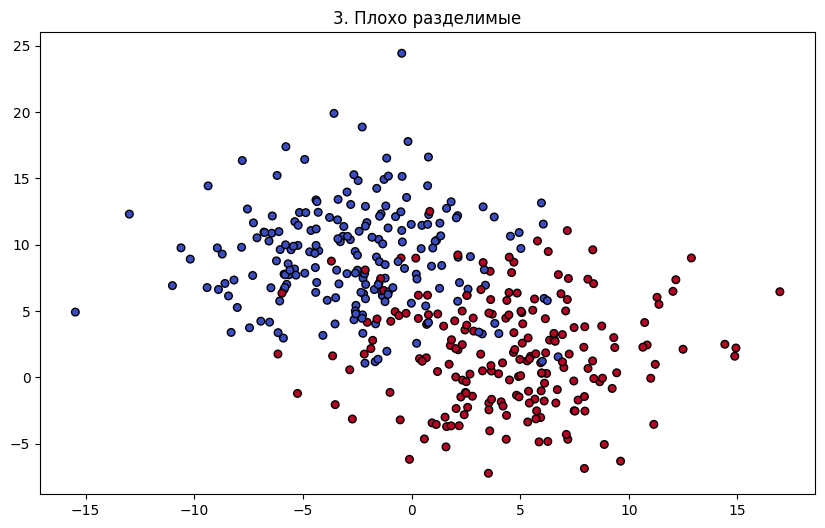

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Настройка размера графиков
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Линейно разделимые (два четких облака)
X1, y1 = make_blobs(n_samples=400, centers=2, cluster_std=1.5, random_state=42)

# 2. Не линейно, но хорошо разделимые (две луны)
X2, y2 = make_moons(n_samples=400, noise=0.1, random_state=42)

# 3. Плохо разделимые (облака наезжают друг на друга)
X3, y3 = make_blobs(n_samples=400, centers=2, cluster_std=4.0, random_state=42)

# Функция для отрисовки
def plot_dataset(X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k')
    plt.title(title)
    plt.show()

# Рисуем
plot_dataset(X1, y1, "1. Линейно разделимые")
plot_dataset(X2, y2, "2. Хорошо разделимые (не линейно)")
plot_dataset(X3, y3, "3. Плохо разделимые")

**2.** Обучите на сгенерированных ранее двумерных выборках [ядровой SVM](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) с использованием следующих типов ядер (для различных значений гиперпараметра $C$):
- линейное: $K(x, z) = \langle x, z \rangle$;
- полиномиальное: $K(x, z) = (\gamma \langle x, z \rangle + 1)^d$ (для различных значений $\gamma, d$);
- гауссовское: $K(x, z) = \exp(-\gamma \|x - z\|^2)$ (для различных значений $\gamma$).

Generating Plot 1: Linear Kernel (Varying C)...


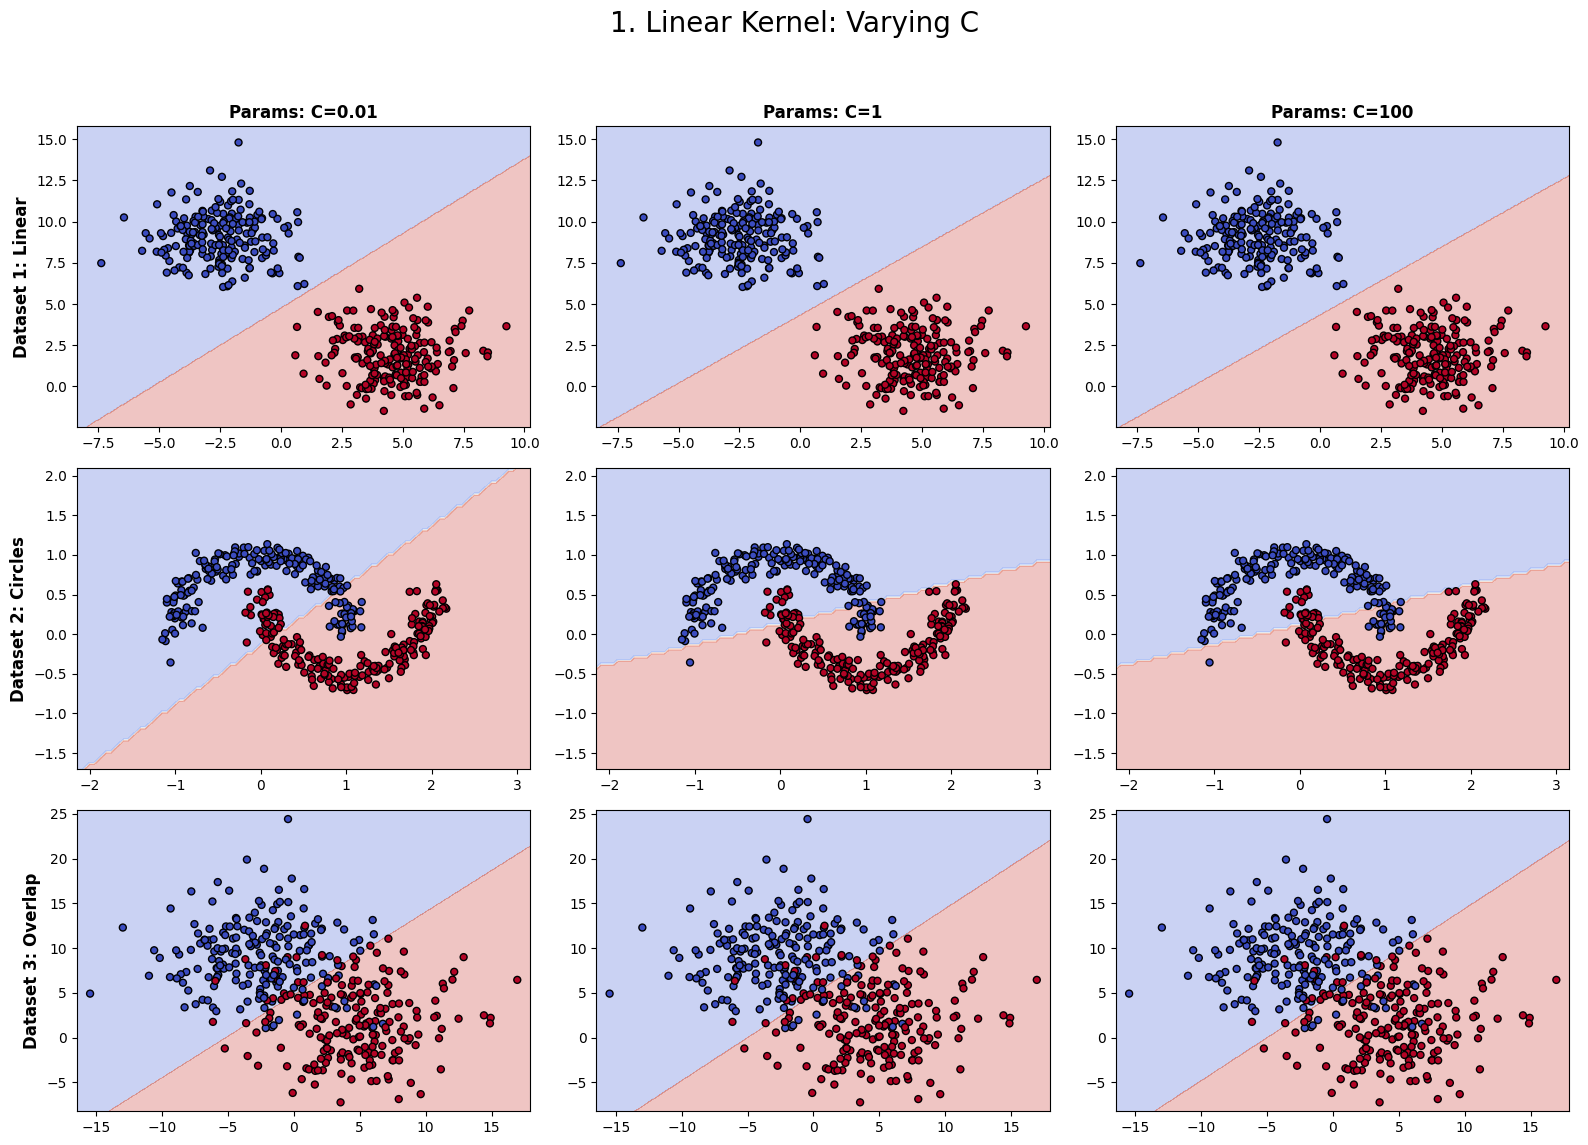

Generating Plot 2: Poly Kernel (Varying Degree/Gamma)...


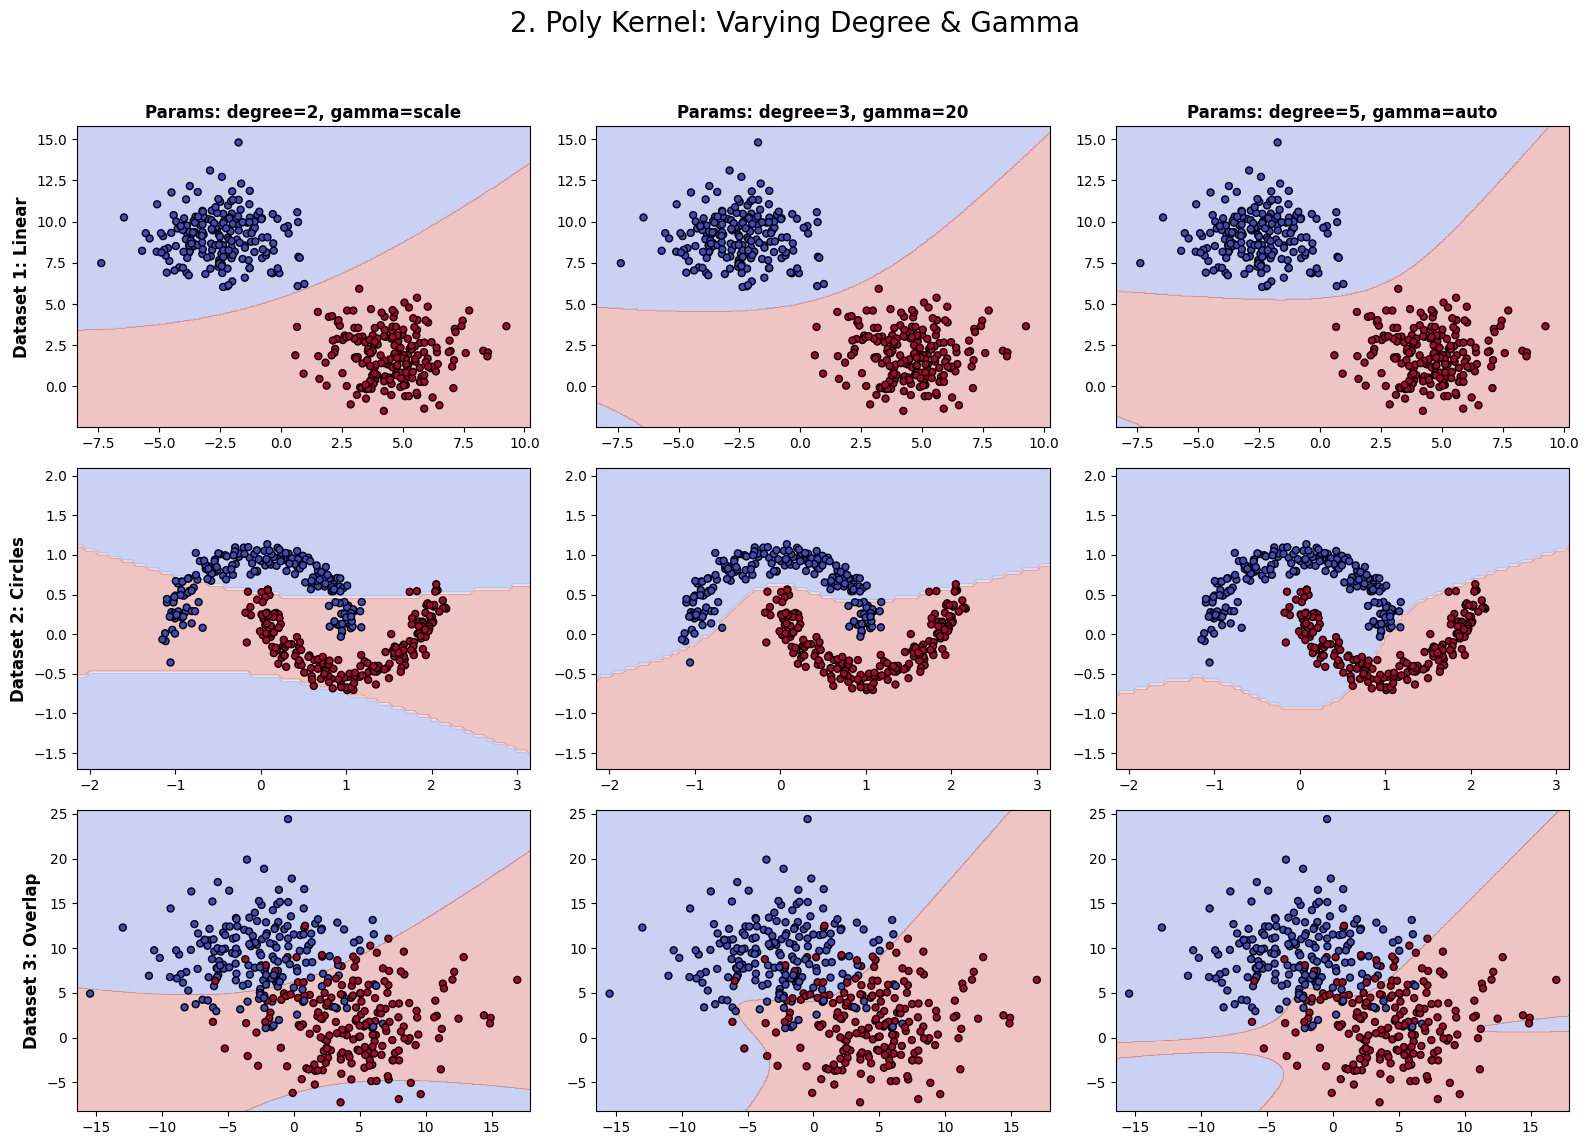

Generating Plot 3: Poly Kernel (Varying C)...


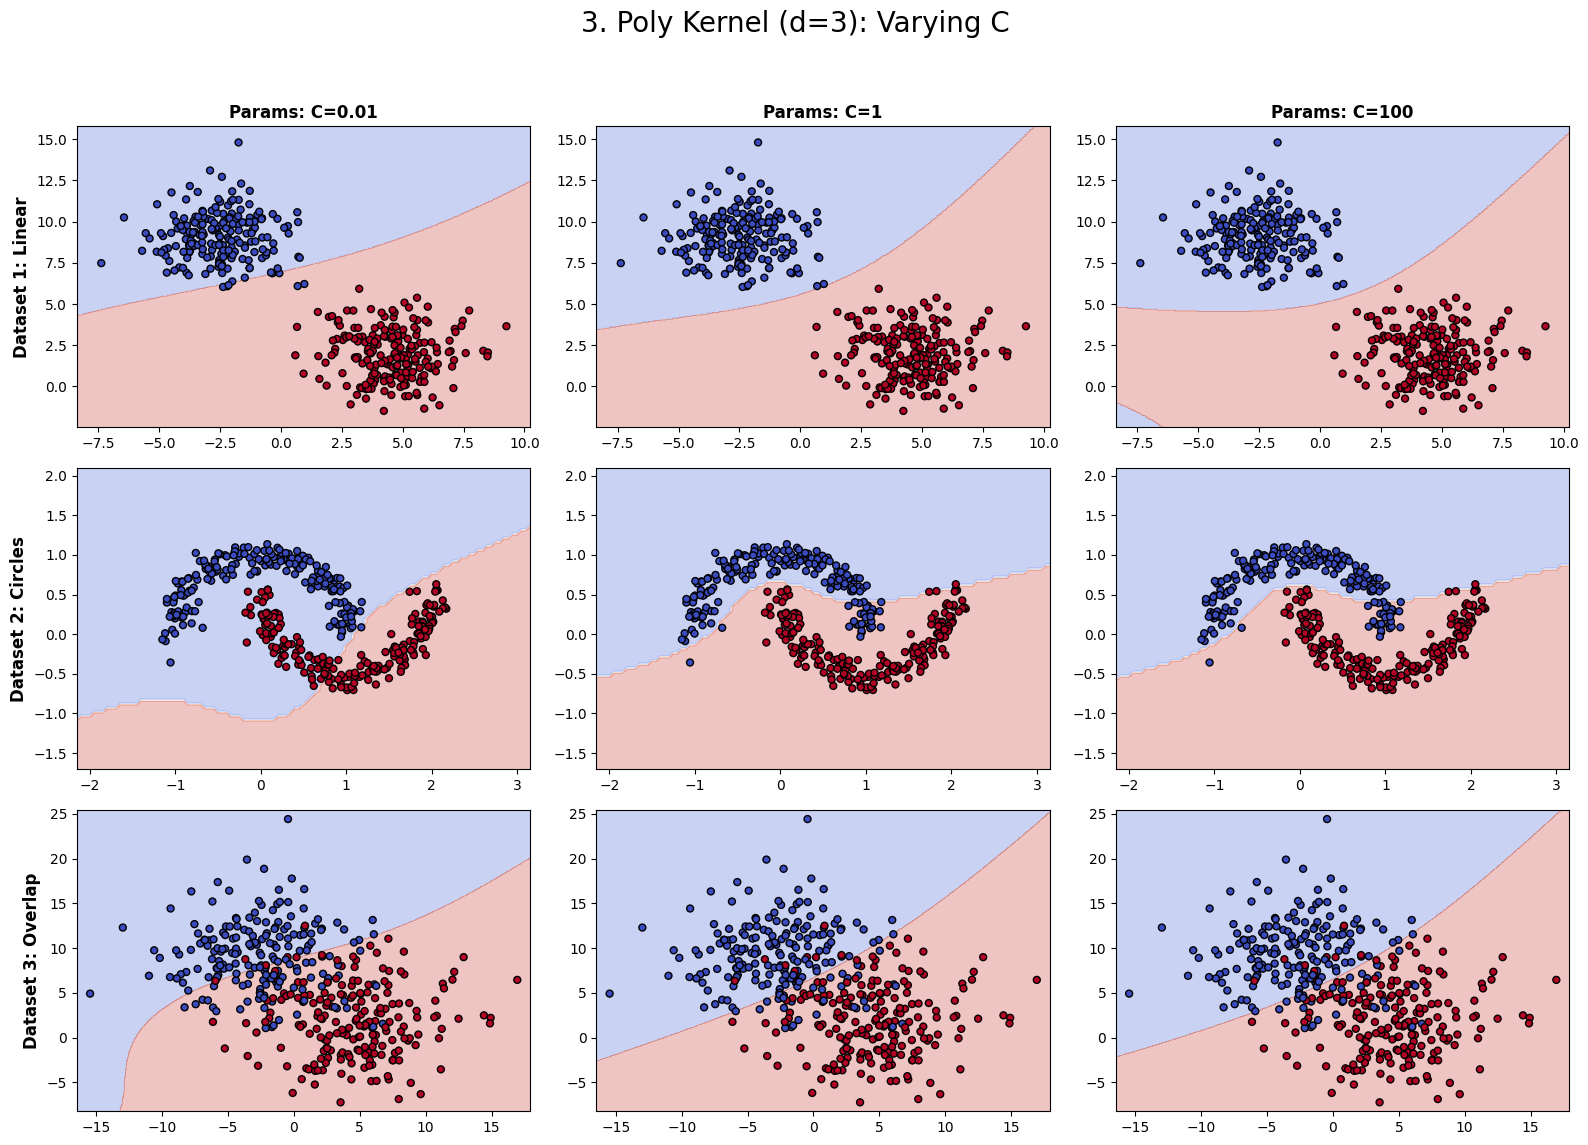

Generating Plot 4: RBF Kernel (Varying Gamma)...


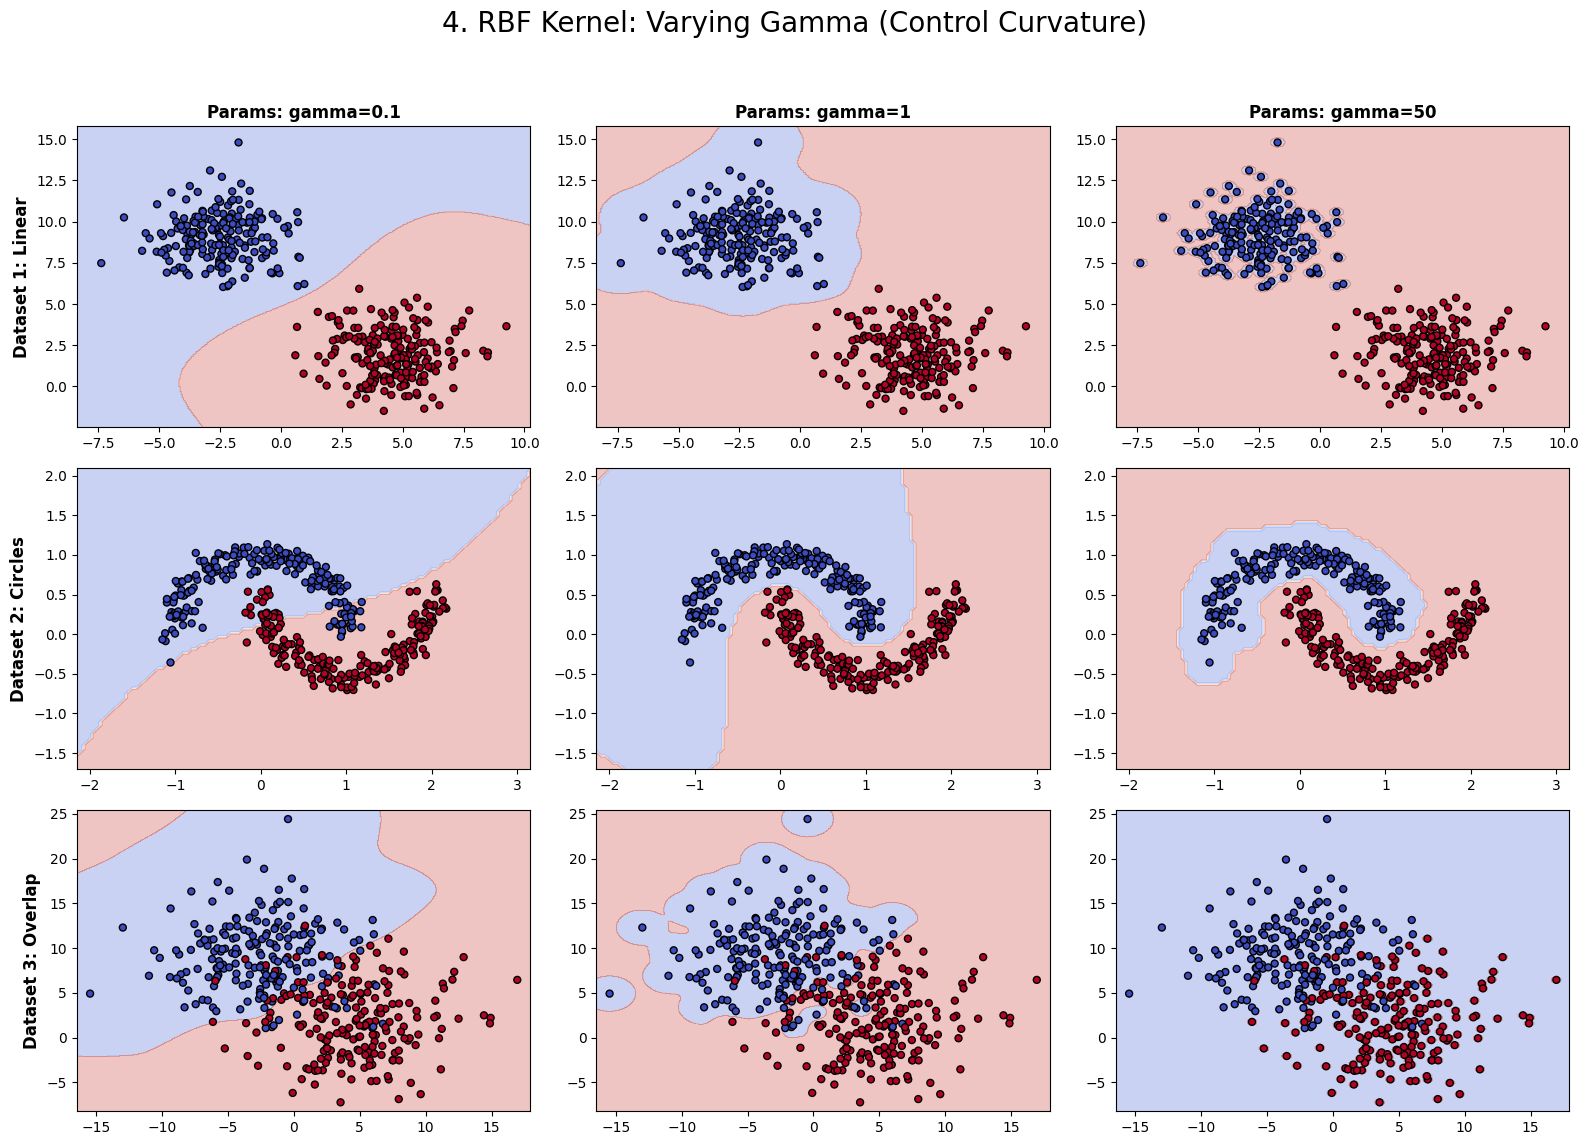

Generating Plot 5: RBF Kernel (Varying C)...


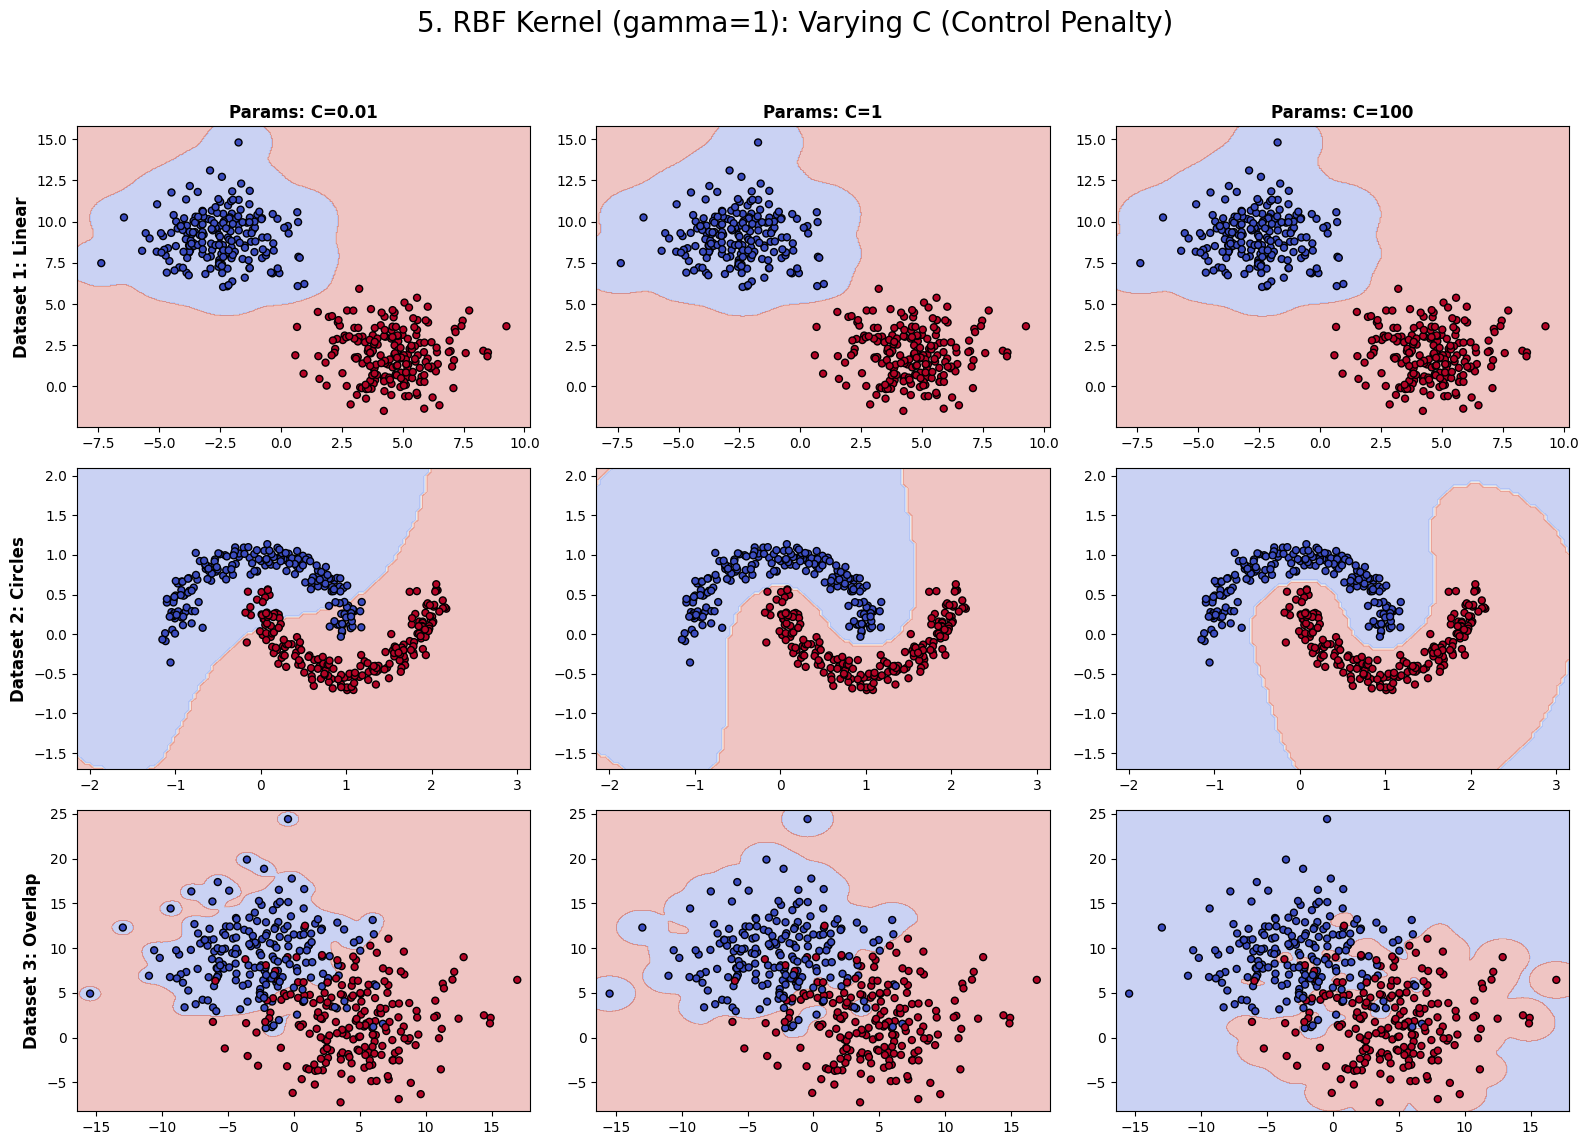

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles

# ---------------------------------------------------------
# 1. ГЕНЕРАЦИЯ ДАННЫХ (X1, X2, X3)
# ---------------------------------------------------------
n_samples = 300
random_state = 42

# Data 1: Линейно разделимые
# X1, y1 = make_blobs(n_samples=n_samples, centers=2, cluster_std=1.2, center_box=(-10.0, 10.0), random_state=random_state)
# X1[y1 == 0] += [4, 4] # Раздвигаем их
# X1[y1 == 1] -= [4, 4]

# # Data 2: Круги (Нелинейные)
# X2, y2 = make_circles(n_samples=n_samples, noise=0.07, factor=0.5, random_state=random_state)

# # Data 3: Плохо разделимые (смешанные)
# X3, y3 = make_blobs(n_samples=n_samples, centers=2, cluster_std=3.0, random_state=random_state)

# Упаковываем datasets в список для удобного цикла
datasets_list = [
    (X1, y1, "Dataset 1: Linear"),
    (X2, y2, "Dataset 2: Circles"),
    (X3, y3, "Dataset 3: Overlap")
]

# ---------------------------------------------------------
# 2. ФУНКЦИЯ ОТРИСОВКИ 3x3
# ---------------------------------------------------------
def plot_3x3_svm(datasets, params_list, kernel_type, main_title, fixed_params=None):
    """
    Рисует сетку 3x3:
    Строки - разные датасеты
    Столбцы - разные параметры
    """
    if fixed_params is None: fixed_params = {}
    
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    fig.suptitle(main_title, fontsize=20, y=0.98)

    # Цикл по строкам (Датасеты)
    for row_idx, (X, y, ds_name) in enumerate(datasets):
        
        # Подготовка сетки для фона
        h = .05 # шаг сетки (чем меньше, тем точнее, но медленнее)
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

        # Цикл по столбцам (Параметры)
        for col_idx, p in enumerate(params_list):
            ax = axes[row_idx, col_idx]
            
            # Объединяем меняющиеся параметры и фиксированные
            current_params = {**p, **fixed_params}
            
            # Обучение
            model = SVC(kernel=kernel_type, **current_params)
            model.fit(X, y)

            # Предсказание фона
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)

            # Рисование
            ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
            ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=25)
            
            # Подписи
            param_str = ", ".join([f"{k}={v}" for k, v in p.items()])
            if row_idx == 0:
                ax.set_title(f"Params: {param_str}", fontsize=12, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(ds_name, fontsize=12, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ---------------------------------------------------------
# 3. ЗАПУСК 5 СЦЕНАРИЕВ
# ---------------------------------------------------------

# --- Сценарий 1: Linear Kernel (меняем C) ---
print("Generating Plot 1: Linear Kernel (Varying C)...")
params_1 = [{'C': 0.01}, {'C': 1}, {'C': 100}]
plot_3x3_svm(datasets_list, params_1, 'linear', "1. Linear Kernel: Varying C")

# --- Сценарий 2: Poly Kernel (меняем Degree и Gamma, C фиксирован) ---
print("Generating Plot 2: Poly Kernel (Varying Degree/Gamma)...")
params_2 = [
    {'degree': 2, 'gamma': 'scale'}, 
    {'degree': 3, 'gamma': 20}, 
    {'degree': 5, 'gamma': 'auto'}
]
plot_3x3_svm(datasets_list, params_2, 'poly', "2. Poly Kernel: Varying Degree & Gamma", fixed_params={'C': 1})

# --- Сценарий 3: Poly Kernel (меняем C, degree фиксирован) ---
print("Generating Plot 3: Poly Kernel (Varying C)...")
params_3 = [{'C': 0.01}, {'C': 1}, {'C': 100}]
plot_3x3_svm(datasets_list, params_3, 'poly', "3. Poly Kernel (d=3): Varying C", fixed_params={'degree': 3, 'gamma': 'scale'})

# --- Сценарий 4: RBF Kernel (меняем Gamma, C фиксирован) ---
print("Generating Plot 4: RBF Kernel (Varying Gamma)...")
params_4 = [{'gamma': 0.1}, {'gamma': 1}, {'gamma': 50}]
plot_3x3_svm(datasets_list, params_4, 'rbf', "4. RBF Kernel: Varying Gamma (Control Curvature)", fixed_params={'C': 1})

# --- Сценарий 5: RBF Kernel (меняем C, Gamma фиксирована) ---
print("Generating Plot 5: RBF Kernel (Varying C)...")
params_5 = [{'C': 0.01}, {'C': 1}, {'C': 100}]
plot_3x3_svm(datasets_list, params_5, 'rbf', "5. RBF Kernel (gamma=1): Varying C (Control Penalty)", fixed_params={'gamma': 1})

**3.** Ответьте на следующие вопросы:
 - Как ведет себя SVM с полиномиальным ядром в зависимости от значений гиперпараметра $C$, степени ядра $d$ и параметра $\gamma$?
 - Как ведет себя SVM с гауссовским ядром в зависимости от значений гиперпараметра $C$ и $\gamma$?

### Резюме в таблице

| Параметр | Увеличение значения ведет к... | 
| --- | --- | 
| **С** | Более строгому разделению, узкому зазору | 
| **d** | Усложнению формы кривой (больше изгибов) | 
| **гамма** | Усилению локального влияния точек | 


**4.** Обучите модели с использованием ядер из п. 2 для задачи бинарной классификации [Predicting a Biological Response](https://www.kaggle.com/c/bioresponse) (используйте файл train.csv) для значения $C=1.$ Для оценки качества разбейте выборку на обучающую и тестовую в отношении 50/50. Постройте модель, позволяющую достичь значения accuracy, равного 0.75, на тестовой выборке. Позволяет ли использование ядер достичь лучшего качества по сравнению с линейной моделью?

In [18]:
# Загрузка данных
df = pd.read_csv('bioresponse.csv')

# Разделение на признаки (X) и целевую переменную (y)
# Посмотрев на файл, видим, что целевая переменная - это колонка 'Activity'
y = df['Activity']
X = df.drop('Activity', axis=1)

# Разбиение на обучение и тест (50/50 по заданию)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

print("Размер обучающей выборки:", X_train.shape)

# --- 1. Линейная модель ---
svm_lin = SVC(kernel='linear', C=1)
svm_lin.fit(X_train, y_train)
pred_lin = svm_lin.predict(X_test)
acc_lin = accuracy_score(y_test, pred_lin)
print(f"Accuracy (Linear): {acc_lin:.4f}")

# --- 2. Полиномиальная модель ---
svm_poly = SVC(kernel='poly', degree=3, C=1, gamma='scale')
svm_poly.fit(X_train, y_train)
pred_poly = svm_poly.predict(X_test)
acc_poly = accuracy_score(y_test, pred_poly)
print(f"Accuracy (Poly): {acc_poly:.4f}")

# --- 3. RBF (Гауссовская) модель ---
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)
pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, pred_rbf)
print(f"Accuracy (RBF): {acc_rbf:.4f}")

Размер обучающей выборки: (1875, 1776)
Accuracy (Linear): 0.7335
Accuracy (Poly): 0.7548
Accuracy (RBF): 0.7713
